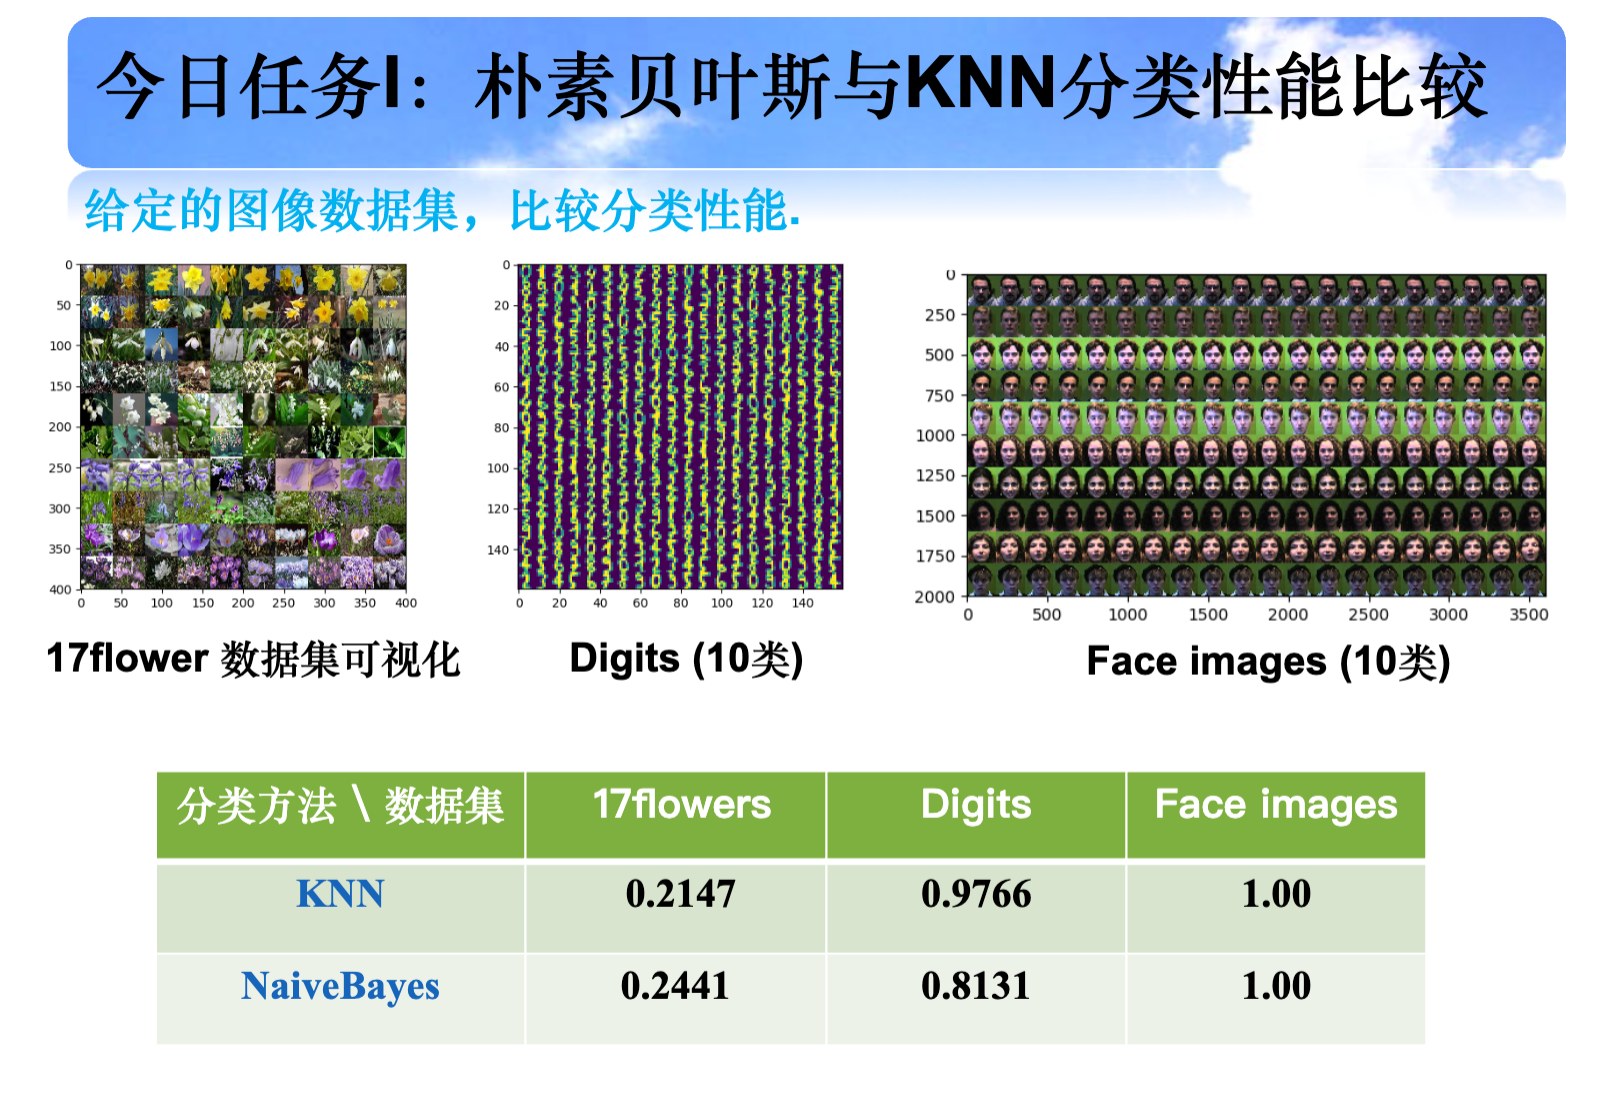

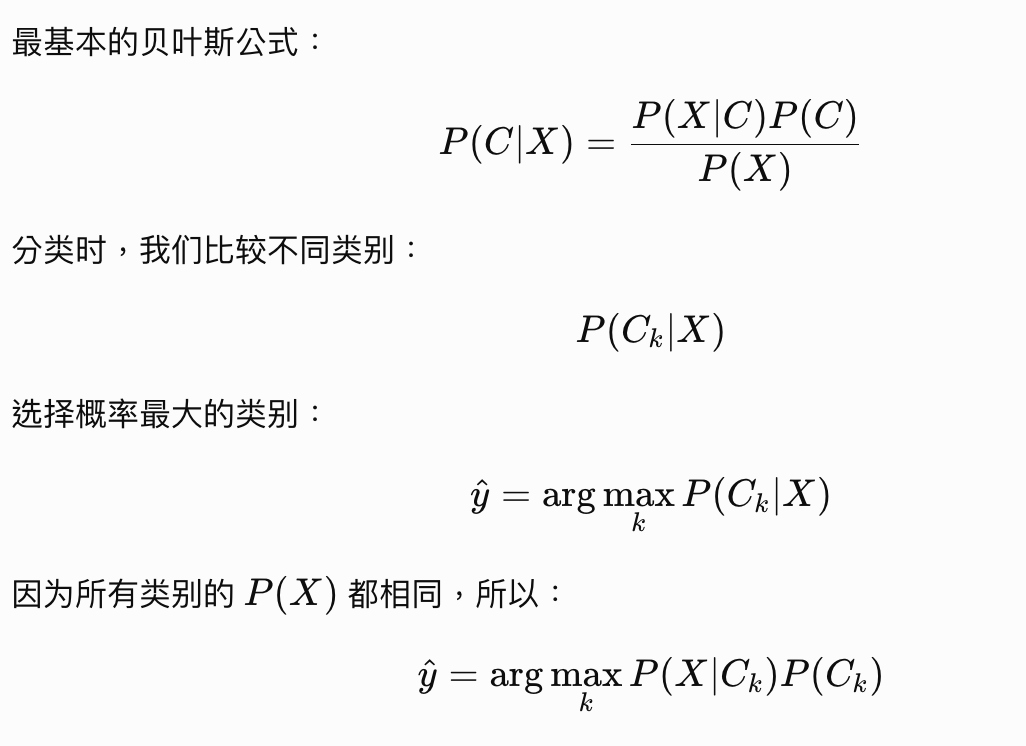

In [2]:
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
data_dir="../dataset/17flowers"




修改读取部分

图片数量： 1360
图片尺寸： (500, 689, 3)


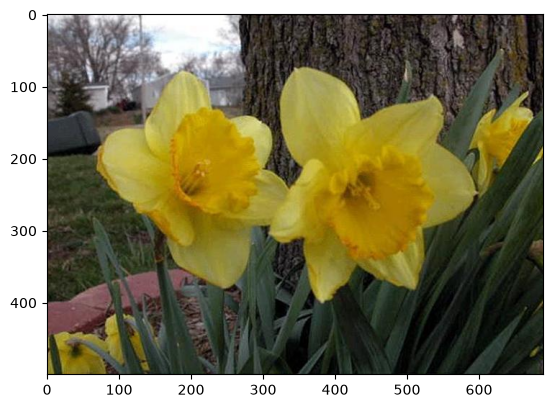

In [3]:
import os
import matplotlib.pyplot as plt

data_dir = "../dataset/17flowers"

flower_img = []

# 读取所有图片
for flower in os.listdir(data_dir):
    if flower.lower().endswith(".jpg"):
        flower_img.append(flower)

flower_img = sorted(flower_img)

print("图片数量：", len(flower_img))

# 确认读取照片尺寸
flower = flower_img[0]

img_path = os.path.join(data_dir, flower)

img = plt.imread(img_path)

print("图片尺寸：", img.shape)

plt.imshow(img)
plt.show()

In [4]:
import os
import numpy as np
from PIL import Image

X = []
y = []

# 统一图片尺寸
img_size = (64, 64)

for filename in flower_img:

    # 1. 建立图片路径
    img_path = os.path.join(data_dir, filename)

    # 2. 读取图片并统一尺寸
    img = Image.open(img_path).convert("RGB")
    img = img.resize(img_size)

    # 3. 转换成 numpy 数组
    img_array = np.array(img)

    # 4. Flatten：三维转一维
    img_flat = img_array.flatten()

    # 5. 加入特征矩阵
    X.append(img_flat)

    # 6. 根据图片编号建立标签
    img_id = int(filename.split("_")[1].split(".")[0])

    label = (img_id - 1) // 80

    y.append(label)

# 转换为 numpy 数组
X = np.array(X, dtype=np.float32)
y = np.array(y)

# 像素归一化
X = X / 255.0

print("X shape:", X.shape)
print("y shape:", y.shape)
print("类别数量:", len(np.unique(y)))

# import numpy as np
# from sklearn.model_selection import train_test_split

# X = np.array(X)
# y = np.array(y)

# print("X shape:", X.shape)
# print("y shape:", y.shape)
# print("类别数量:", len(np.unique(y)))

X shape: (1360, 12288)
y shape: (1360,)
类别数量: 17


In [5]:







# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

#计算准确率

from sklearn.metrics import accuracy_score

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy =", acc_knn)

# Gaussian Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy =", acc_nb)

# 输出
print("KNN Accuracy =", acc_knn)
print("Naive Bayes Accuracy =", acc_nb)


KNN Accuracy = 0.3235294117647059
Naive Bayes Accuracy = 0.40808823529411764
KNN Accuracy = 0.3235294117647059
Naive Bayes Accuracy = 0.40808823529411764


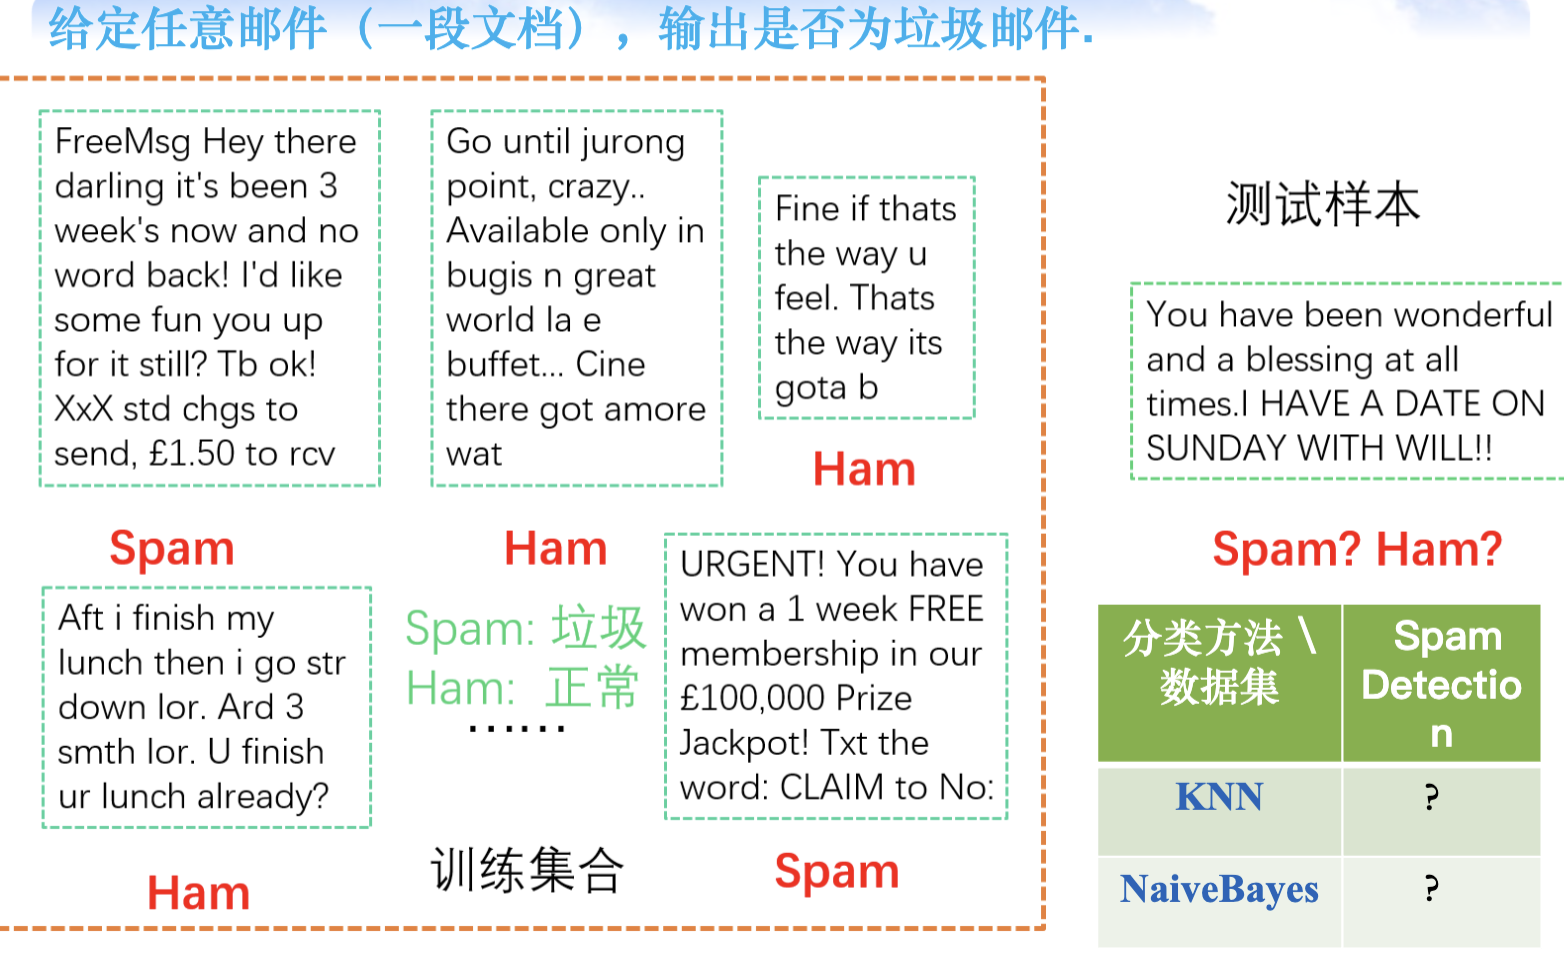

TF-IDF 将邮件变成向量

In [6]:
data_path = "./Ch6-word2vec/SpamEmailDetector/emails/training/SMSCollection.txt"

with open(data_path, "r", encoding="utf-8") as f:
    for i in range(5):
        print(repr(f.readline()))
        
import pandas as pd

data = pd.read_csv(
    "./Ch6-word2vec/SpamEmailDetector/emails/training/SMSCollection.txt",
    sep="\t",
    header=None,
    names=["label", "text"],
    encoding="utf-8"
)

print(data.head())
print(data.shape)
print(data["label"].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: './Ch6-word2vec/SpamEmailDetector/emails/training/SMSCollection.txt'

In [ ]:

X = data["text"]
y = data["label"]

# 划分训练集和测试集

# 全部 5572 封
# ↓ 80%
# 训练集
# ↓ 20%
# 测试集

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

# 训练集
X_train_vec = vectorizer.fit_transform(X_train)
# 测试集
X_test_vec = vectorizer.transform(X_test)


# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_vec, y_train)

y_pred_knn = knn.predict(X_test_vec)

from sklearn.metrics import accuracy_score

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy =", acc_knn)


# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy =", acc_nb)


# GaussianNB
#     ↓
# 连续型特征

# MultinomialNB
#     ↓
# 词频 / TF-IDF 等非负文本特征

test_email = [
    "You have been wonderful and a blessing at all times. "
    "I HAVE A DATE ON SUNDAY WITH WILL!!"
]

test_vec = vectorizer.transform(test_email)

print("KNN:", knn.predict(test_vec)[0])
print("Naive Bayes:", nb.predict(test_vec)[0])




KNN Accuracy = 0.9264573991031391
Naive Bayes Accuracy = 0.9605381165919282
KNN: ham
Naive Bayes: ham


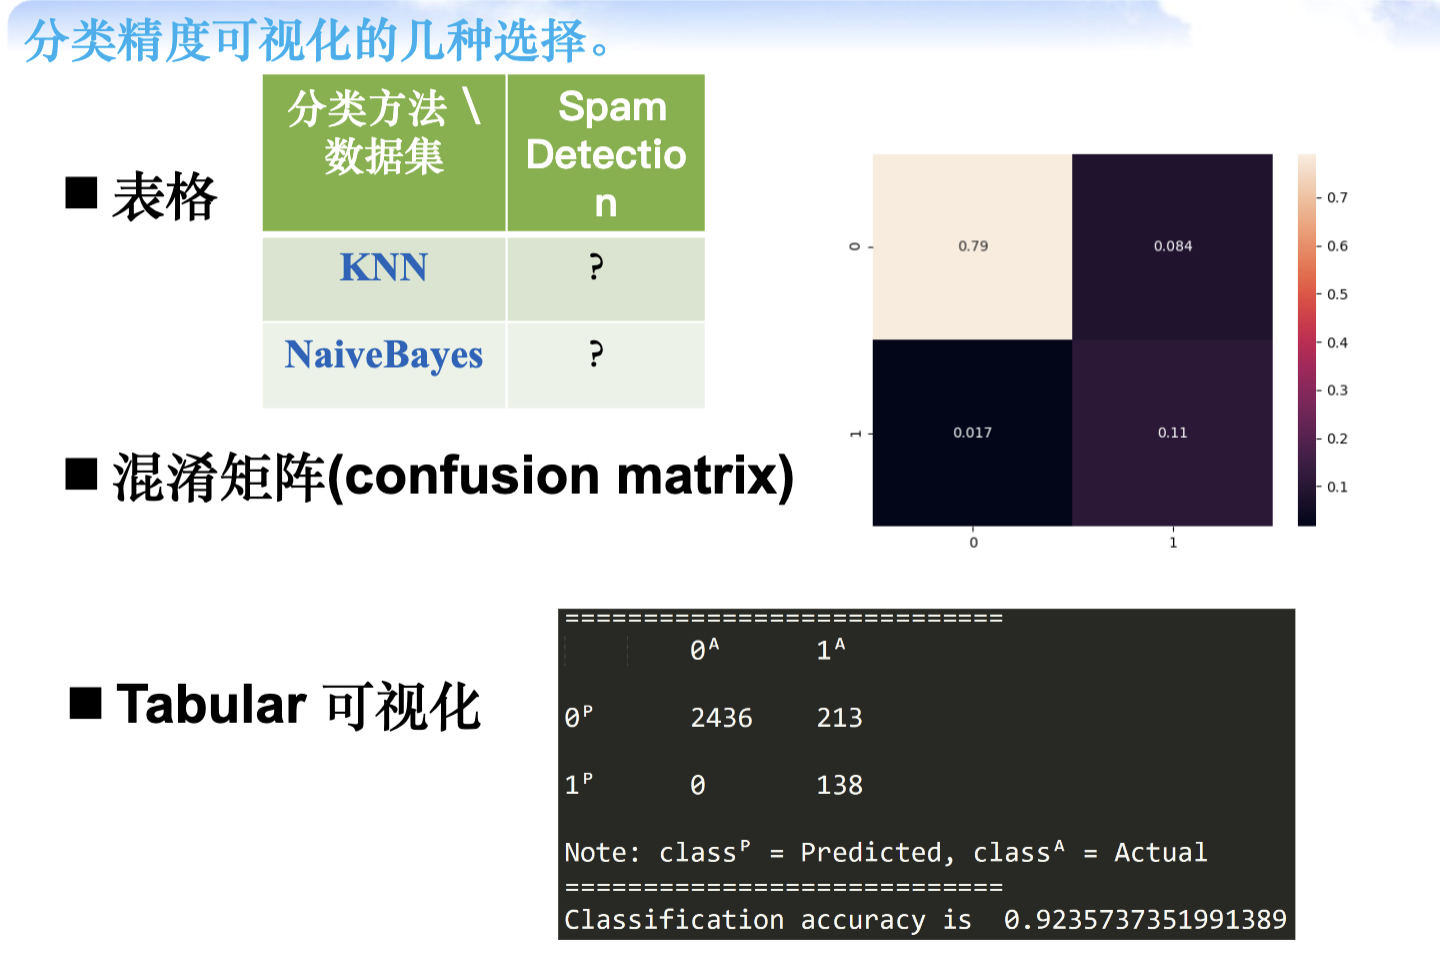

In [ ]:
result = pd.DataFrame({
    "Method": ["KNN", "NaiveBayes"],
    "Spam Detection": [
        acc_knn,
        acc_nb
    ]
})

print(result)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_nb
)

print(cm)

#                   实际
#               Ham      Spam
# 预测 Ham      TN        FN
# 预测 Spam     FP        TP

# TP = True Positive
# TN = True Negative
# FP = False Positive
# FN = False Negative

       Method  Spam Detection
0         KNN        0.926457
1  NaiveBayes        0.960538
[[966   0]
 [ 44 105]]
